In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt


/data/ll2531/venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
with open("processed_data_pkl/imputed_training_data.pkl", "rb") as f:
    traffic_dic = pickle.load(f)

with open("processed_data_pkl/weather_global_2014_2025.pkl", "rb") as f:
    weather = pickle.load(f)

air_qual = pd.read_csv("online_data/air_qual/air_qual.csv")

In [3]:
air_qual.drop(columns=["aerosol_optical_depth ()", "dust (μg/m³)"], inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(inplace=True, drop=True)

In [4]:
air_qual["time"] = pd.to_datetime(air_qual["time"], errors="coerce")
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

weather = weather[weather["timestamp"].isin(air_qual["time"])]
weather.reset_index(inplace=True, drop=True)

In [5]:
dataset = pd.concat([weather, air_qual], axis=1)
dataset.drop(columns=["time"], inplace=True)

In [6]:
dataset

,dew_point_2m (°C),relative_humidity_2m (%),precipitation (mm),weather_code (wmo code),wind_speed_100m (km/h),wind_direction_10m (°),cloud_cover_high (%),cloud_cover_mid (%),cloud_cover_low (%),cloud_cover (%),surface_pressure (hPa),timestamp,pm10 (μg/m³),pm2_5 (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),carbon_monoxide (μg/m³),ozone (μg/m³)
0,1.5,88,0.0,0,22.3,233,0,0,0,0,1011.8,2016-01-01 00:00:00,12.7,5.9,22.0,3.0,188.0,34.0
1,1.0,91,0.0,0,16.8,210,14,0,0,14,1012.1,2016-01-01 01:00:00,16.5,8.6,19.0,4.1,198.0,26.0
2,0.1,92,0.0,0,15.9,189,1,0,0,1,1012.1,2016-01-01 02:00:00,21.0,12.6,20.4,4.4,202.0,27.0
3,-0.4,94,0.0,2,19.1,182,75,2,0,76,1012.8,2016-01-01 03:00:00,15.4,10.3,20.8,2.7,207.0,23.0
4,-0.5,94,0.0,3,19.7,170,100,90,0,100,1012.9,2016-01-01 04:00:00,15.7,9.1,23.0,2.2,164.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87667,-1.5,97,0.0,2,23.3,250,0,0,77,77,1017.5,2025-12-31 19:00:00,18.3,12.6,21.5,2.0,215.0,35.0
87668,-1.7,95,0.0,1,24.7,254,0,0,21,21,1016.9,2025-12-31 20:00:00,17.0,12.0,21.2,2.4,225.0,37.0
87669,-1.8,93,0.0,1,26.3,254,0,0,31,31,1015.9,2025-12-31 21:00:00,15.9,11.6,18.2,2.3,225.0,39.0
87670,-1.5,92,0.0,1,28.0,252,0,0,41,41,1014.6,2025-12-31 22:00:00,15.4,10.9,22.6,2.4,250.0,42.0


# rf base line with lag

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns

In [8]:
air_qual_no_time = dataset.drop(columns=["timestamp"]).copy()

In [9]:
df = air_qual.copy()

# Create lag features
for col in [
    "pm10 (μg/m³)",
    "pm2_5 (μg/m³)",
    "nitrogen_dioxide (μg/m³)",
    "sulphur_dioxide (μg/m³)",
    "carbon_monoxide (μg/m³)",
    "ozone (μg/m³)"
]:
    df[f"{col}_lag1"] = df[col].shift(1)
    df[f"{col}_lag3"] = df[col].shift(3)

# Target is current PM2.5
y = df["pm2_5 (μg/m³)"]

# Keep ONLY lagged features
x = df[[c for c in df.columns if "_lag" in c]]

# Remove rows with NaNs from shifting
mask = x.notna().all(axis=1)
x = x[mask]
y = y[mask]

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)

pred = rf.predict(x_test)

In [11]:
pred = rf.predict(x_test)
r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)

print("MAE", mae)
print("RMSE", np.sqrt(mean_squared_error(y_test, pred)))
print("R2", r2)

MAE 0.613991388160146
RMSE 0.9652411813103557
R2 0.9701230428704614


# lstm

In [12]:
dataset.set_index("timestamp", inplace=True)

In [13]:
# Separate features and target
features_df = dataset.drop(columns=["pm2_5 (μg/m³)"])
target_df = dataset[["pm2_5 (μg/m³)"]]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_X = scaler_X.fit_transform(features_df)
scaled_y = scaler_y.fit_transform(target_df)

lookback = 24*5
forecast_steps = 24 
# Construct inputs/outputs safely
x = []
y = []
for i in range(lookback, len(dataset) - forecast_steps + 1):
    x.append(scaled_X[i-lookback:i, :])
    y.append(scaled_y[i:i+forecast_steps, 0])

x = np.array(x)
y = np.array(y)

In [14]:
# Train/Test Split
split = int(len(x) * 0.7)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

In [15]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Layer
import tensorflow.keras.backend as K

class SimpleAttention(Layer):
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="normal", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                 initializer="zeros", trainable=True)
        super(SimpleAttention, self).build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        e = K.squeeze(e, axis=-1)
        alpha = K.softmax(e)
        alpha = K.expand_dims(alpha, axis=-1)
        context = x * alpha
        return K.sum(context, axis=1)

inputs = Input(shape=(x_train.shape[1], x_train.shape[2]))

lstm_1 = LSTM(256, return_sequences=True)(inputs)
drop_1 = Dropout(0.2)(lstm_1)

lstm_2 = LSTM(128, return_sequences=True)(drop_1) 
drop_2 = Dropout(0.2)(lstm_2)

lstm_3 = LSTM(64, return_sequences=True)(drop_2) 
drop_3 = Dropout(0.2)(lstm_3)

attention_out = SimpleAttention()(drop_2)

dense_1 = Dense(64, activation="relu")(attention_out)
dense_2 = Dense(32, activation="relu")(dense_1)
outputs = Dense(forecast_steps)(dense_2)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer="adam", loss="mse")

model.summary()

2026-06-08 19:11:28.928864: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-08 19:11:28.965584: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-08 19:11:29.883650: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:17809422

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 120, 256)       │       279,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 120, 128)       │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_attention                │ (None, 128)            │           248 │
│ (SimpleAttention)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 488,048 (1.86 MB)

 Trainable params: 488,048 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
hist = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=40, batch_size=32)

Epoch 1/40


2026-06-08 19:11:33.679041: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


1915/1915 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 0.0047 - val_loss: 0.0033
Epoch 2/40
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0033 - val_loss: 0.0027
Epoch 3/40
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 4/40
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0024 - val_loss: 0.0030
Epoch 5/40
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0021 - val_loss: 0.0030
Epoch 6/40
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0016 - val_loss: 0.0030
Epoch 7/40
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0013 - val_loss: 0.0031
Epoch 8/40
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0011 - val_loss: 0.0032
Epoch 9/40
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 9.2737e-04 - val_loss: 0.0033
Epoch 10/40
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 8.1931e-04 - val_loss: 0.0032
Epoch 11/40
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 7.1823e-04 - val_loss: 0.0033
Epoch 1

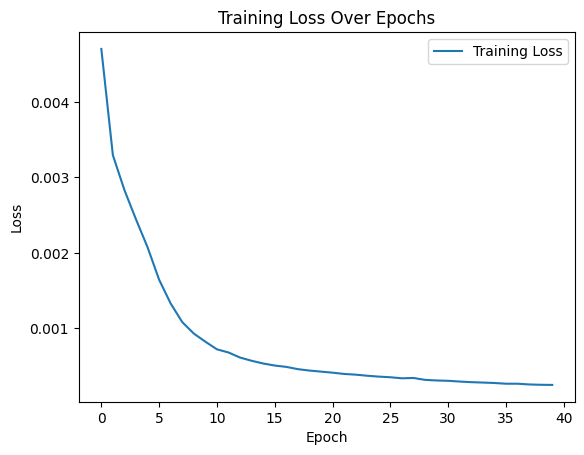

In [17]:
plt.plot(hist.history["loss"], label="Training Loss")
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [18]:
pred = model.predict(x_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

821/821 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
MAE: 0.041127045656309
RMSE: 0.05771159732884251
R²: 0.3519425854565357


In [19]:
import plotly.graph_objects as go


y_test_pred_rescaled = scaler_y.inverse_transform(pred)
y_test_true_rescaled = scaler_y.inverse_transform(y_test)

test_start_idx = split + lookback
pm25_raw = air_qual["pm2_5 (μg/m³)"].values

# Timeline Arrays for X-axis positioning
history_x = list(range(lookback))
forecast_x = list(range(lookback, lookback + forecast_steps))

fig = go.Figure()

sample_idx = 0
global_start = test_start_idx + sample_idx

fig.add_trace(go.Scatter(
    x=history_x, 
    y=pm25_raw[global_start - lookback : global_start],
    mode='lines+markers', name='Historical PM2.5', line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=forecast_x, 
    y=y_test_true_rescaled[sample_idx],
    mode='lines+markers', name='Actual Future', line=dict(color='green', dash='dash')
))

fig.add_trace(go.Scatter(
    x=forecast_x, 
    y=y_test_pred_rescaled[sample_idx],
    mode='lines+markers', name='Predicted Forecast', line=dict(color='red')
))

# 2. Build the dropdown menus for the first 50 test samples
num_samples_to_show = min(50, len(x_test))
buttons = []

for idx in range(num_samples_to_show):
    visibility = [False] * (num_samples_to_show * 3)
    visibility[idx * 3] = True
    visibility[idx * 3 + 1] = True
    visibility[idx * 3 + 2] = True
    
    button = dict(
        label=f"Sample {idx}",
        method="update",
        args=[
            {"visible": visibility},
            {"title": f"PM2.5 Timeline: 24h History + 5-Step Forecast (Sample {idx})"}
        ]
    )
    buttons.append(button)

# 3. Generate all remaining hidden traces for the selector upfront
for idx in range(1, num_samples_to_show):
    g_start = test_start_idx + idx
    fig.add_trace(go.Scatter(
        x=history_x, y=pm25_raw[g_start - lookback : g_start],
        mode='lines+markers', name='Historical PM2.5', line=dict(color='blue'), visible=False
    ))
    # Actual
    fig.add_trace(go.Scatter(
        x=forecast_x, y=y_test_true_rescaled[idx],
        mode='lines+markers', name='Actual Future', line=dict(color='green', dash='dash'), visible=False
    ))
    # Predicted
    fig.add_trace(go.Scatter(
        x=forecast_x, y=y_test_pred_rescaled[idx],
        mode='lines+markers', name='Predicted Forecast', line=dict(color='red'), visible=False
    ))

# 4. Final Layout Customization
fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, direction="down", pad={"r": 10, "t": 10}, showactive=True, x=0.02, xanchor="left", y=1.15, yanchor="top")],
    title="PM2.5 Timeline: 24h History + 5-Step Forecast (Sample 0)",
    xaxis_title="Timeline (Hours)",
    yaxis_title="PM2.5 Concentration (μg/m³)",
    height=600,
    showlegend=True
)

fig.add_vline(x=23.5, line_width=2, line_dash="dash", line_color="gray")

fig.show()

# darts 

In [ ]:
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import TFTModel

target_series = TimeSeries.from_dataframe(dataset, value_cols="pm2_5 (μg/m³)")
feature_cols = [col for col in dataset.columns if col != "pm2_5 (μg/m³)"]
past_covariates_series = TimeSeries.from_dataframe(dataset, value_cols=feature_cols)

# Define lookback and forecast steps
lookback = 24 * 2  # 120 steps
forecast_steps = 12

split_point = 0.70
train_target, val_target = target_series.split_before(split_point)
train_covariates, val_covariates = past_covariates_series.split_before(split_point)

# 3. Scaling using Darts' built-in Scaler
scaler_target = Scaler()
scaler_covariates = Scaler()

train_target_scaled = scaler_target.fit_transform(train_target)
val_target_scaled = scaler_target.transform(val_target)

train_covariates_scaled = scaler_covariates.fit_transform(train_covariates)
val_covariates_scaled = scaler_covariates.transform(val_covariates)

In [ ]:
from darts.models import TransformerModel
model_transformer = TransformerModel(
    input_chunk_length=lookback, # Fixed to match your intended lookback (120)
    output_chunk_length=forecast_steps,
    d_model=80,
    nhead=8,
    num_encoder_layers=4,
    num_decoder_layers=4,
    dropout=0.15,
    dim_feedforward=512,
    n_epochs=30
)
model_transformer.fit(
    series=train_target_scaled,
    past_covariates=train_covariates_scaled,
    val_series=val_target_scaled,
    val_past_covariates=val_covariates_scaled,
    verbose=True
)


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 22.1 M | train
-------------------------------------------------------------
22.1 M    Trainable params
13.5 K    Non-tr

Epoch 29: 100%|██████████| 1914/1914 [01:19<00:00, 23.94it/s, train_loss=0.000293, val_loss=0.00316]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 1914/1914 [01:19<00:00, 23.94it/s, train_loss=0.000293, val_loss=0.00316]


NBEATSModel(output_chunk_shift=0, generic_architecture=True, num_stacks=30, num_blocks=1, num_layers=4, layer_widths=256, expansion_coefficient_dim=5, trend_polynomial_degree=2, dropout=0.0, activation=ReLU, input_chunk_length=120, output_chunk_length=24, n_epochs=30, random_state=42)

In [ ]:
pred_scaled = model_transformer.historical_forecasts(
    series=val_target_scaled,
    past_covariates=val_covariates_scaled,
    start=lookback,                
    forecast_horizon=forecast_steps,
    stride=1,                      
    retrain=False,
    last_points_only=False        
)

# Inverse scale predictions back to raw PM2.5 values
pred_rescaled = [scaler_target.inverse_transform(p) for p in pred_scaled]

# --- Metric Evaluation Fix ---
backtest_scaled = model_transformer.historical_forecasts(
    series=val_target_scaled, past_covariates=val_covariates_scaled,
    start=lookback, forecast_horizon=forecast_steps, stride=1, retrain=False, last_points_only=True
)
backtest_rescaled = scaler_target.inverse_transform(backtest_scaled)

print("Validation Metrics (Backtest):")
print("MAE:", mae(val_target, backtest_rescaled))
print("RMSE:", rmse(val_target, backtest_rescaled))
print("R²:", r2_score(val_target, backtest_rescaled))

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 136.08it/s]
MAE: 6.919443048701583
RMSE: 6.991410545133416
R²: -46.437746849264826


In [ ]:
num_samples_to_show = min(50, len(pred_rescaled))

history_x = list(range(lookback))
forecast_x = list(range(lookback, lookback + forecast_steps))

fig = go.Figure()
buttons = []
total_traces_per_sample = 3

for idx in range(num_samples_to_show):
    visibility = [False] * (num_samples_to_show * total_traces_per_sample)
    visibility[idx * total_traces_per_sample : (idx + 1) * total_traces_per_sample] = [True, True, True]
    
    current_forecast_ts = pred_rescaled[idx]
    forecast_start_time = current_forecast_ts.start_time()
    
    historical_slice = target_series[:forecast_start_time]
    if len(historical_slice) >= lookback:
        history_y = historical_slice.values()[-lookback:].flatten()
    else:
        history_y = historical_slice.values().flatten()
        # Pad x-axis if history is shorter than lookback
        history_x = list(range(lookback - len(history_y), lookback))
    
    # 2. Actual Future Target Slice
    actual_slice = val_target.slice_intersect(current_forecast_ts)
    actual_y = actual_slice.values().flatten()
    
    # 3. Predicted Future Target Slice
    pred_y = current_forecast_ts.values().flatten()
    
    is_visible = True if idx == 0 else False
    
    # Trace 1: Historical Data
    fig.add_trace(go.Scatter(
        x=history_x, y=history_y, mode='lines+markers', 
        name='Historical PM2.5', line=dict(color='blue'), visible=is_visible
    ))
    
    # Trace 2: Actual Future
    fig.add_trace(go.Scatter(
        x=forecast_x, y=actual_y, mode='lines+markers', 
        name='Actual Future', line=dict(color='green', dash='dash'), visible=is_visible
    ))
    
    # Trace 3: Predicted Forecast
    fig.add_trace(go.Scatter(
        x=forecast_x, y=pred_y, mode='lines+markers', 
        name='Predicted Forecast', line=dict(color='red'), visible=is_visible
    ))
    
    # Build dropdown item
    button = dict(
        label=f"Sample {idx}",
        method="update",
        args=[
            {"visible": visibility},
            {"title": f"PM2.5 Timeline: History + Forecast Horizon (Sample {idx})"}
        ]
    )
    buttons.append(button)

fig.update_layout(
    updatemenus=[dict(
        active=0, buttons=buttons, direction="down", 
        pad={"r": 10, "t": 10}, showactive=True, 
        x=0.02, xanchor="left", y=1.15, yanchor="top"
    )],
    title="PM2.5 Timeline: History + Forecast Horizon (Sample 0)",
    xaxis_title="Timeline (Steps)",
    yaxis_title="PM2.5 Concentration (μg/m³)",
    height=600,
    showlegend=True
)

fig.add_vline(x=lookback - 0.5, line_width=2, line_dash="dash", line_color="gray")

fig.show()

AttributeError: 'TimeSeries' object has no attribute 'slice_before'